#### ReActAgent Architecture

#### AIM:

This is intuition behind ReAct, a general agent architecture
1. act - Let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next(e.g. call another call or just respond directly)

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [6]:
from dotenv import load_dotenv
load_dotenv

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANCHAIN_API_KEY"] = os.getenv("LANCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct-agent"

In [7]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a * b

# THis will be tool
def add(a: int, b: int) -> int:
    """Add a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> int:
    """Divide a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [arxiv, wiki, add, multiply, divide]


In [8]:
## Travily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\venke\AppData\Local\Temp\ipykernel_39152\418195978.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [9]:
tavily.invoke("Provide me recent AI news for march 3rd 2025")

[{'title': 'AI Daily News March 03 2025: …–AI Unraveled: Latest AI News ...',
  'url': 'https://podcasts.apple.com/ca/podcast/ai-daily-news-march-03-2025-nvidia-ceo-us-ai-chips/id1684415169?i=1000697521476',
  'content': "Nvidia claims a significant lead in AI chip speed over China, while Apple faces delays in its Siri AI overhaul. New AI applications are emerging, including highly realistic voice generation, automated resume screening, and AI cardiologists in China.OpenAI plans to integrate Sora video AI into ChatGPT, and large investments are being made in AI by companies like Honor and SoftBank. AI is also showing promise in healthcare with tools for cancer detection and improved patient care, but concerns exist about algorithmic bias and the financial sustainability of some AI models. Finally, AI is anticipated to surpass human coding abilities, with models like Claude being evaluated for scientific and national security purposes and Samsung launching AI-powered devices to rival Ap

In [10]:
## Intialize my LLM model

from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")

llm_with_tools = llm.bind_tools(tools)

In [11]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent AI news. Let me see which tool I can use here. The available tools are arxiv, wikipedia, add, multiply, divide. The arxiv tool is for scientific articles in fields like Physics, Math, CS, etc. Wikipedia is for general knowledge. The other tools are for math operations.\n\nSince the user wants recent news, arxiv might have the latest research papers on AI. Wikipedia might have summaries of recent developments. But arxiv is more about recent publications. Let me check the descriptions again. The arxiv tool\'s description says it\'s useful for answering questions about scientific articles on arxiv.org. So if the user wants recent AI news, searching arxiv for AI-related papers would be appropriate. The query parameter should be a search term. So I should call arxiv with the query "AI News" or maybe "recent AI research". Wait, the user said "recent AI News", so maybe the query should be "recen

In [12]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'arxiv',
  'args': {'query': 'recent AI developments'},
  'id': 'jenmdb4j2',
  'type': 'tool_call'}]

In [14]:
# State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

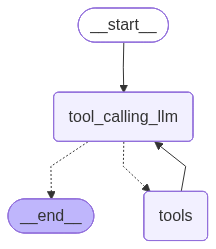

In [18]:
## Entire Chatbot With Langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph =  builder.compile()

#view
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
messages=graph.invoke({"messages": HumanMessage(content="Provide me the top 10 recent AI news for March 3rd 2025, add 5 plus 5 and then multiply by 10 ")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for March 3rd 2025, add 5 plus 5 and then multiply by 10 
================================== Ai Message ==================================
Tool Calls:
  add (awekjt6k3)
 Call ID: awekjt6k3
  Args:
    a: 5
    b: 5
  multiply (17bs0xahf)
 Call ID: 17bs0xahf
  Args:
    a: 10
    b: 10
  arxiv (5e4d65yh4)
 Call ID: 5e4d65yh4
  Args:
    query: AI breakthroughs March 3 2025
================================= Tool Message =================================
Name: add

10
================================= Tool Message =================================
Name: multiply

100
================================= Tool Message =================================
Name: arxiv

Published: 2025-09-03
Title: VQualA 2025 Challenge on Engagement Prediction for Short Videos: Methods and Results
Authors: Dasong Li, Sizhuo Ma, Hang Hua, Wenjie Li, Jian Wang, Chris Wei Zhou, Fengbin Guan, Xin Li, Z

In [20]:
messages=graph.invoke({"messages": HumanMessage(content="what is machine learning ")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is machine learning 
================================== Ai Message ==================================
Tool Calls:
  wikipedia (vh4ssb29a)
 Call ID: vh4ssb29a
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
================================== Ai Message ==================================

Machine learning (ML) is a field of ar

### Agent Memory

#### Aim

Lets introduce Agent with memory

In [21]:
messages=graph.invoke({"messages": HumanMessage(content="what is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (zkz5pdjsb)
 Call ID: zkz5pdjsb
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

The sum of 5 and 8 is **13**.


In [22]:
messages = [HumanMessage(content="Divide that by 5")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

The user is asking to divide a number by 5, but the specific number to divide is not provided in the query. To proceed, I need the user to clarify which number they want divided by 5.

Would you please provide the number you'd like me to divide by 5?


#### MemorySaver

LangGraph can use a checkpointer to automatically save the graph state  after each step.

This built-in peristence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointer to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with checkpointer, and our graph has memory



In [23]:
## Entire Chatbot With Langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

# graph =  builder.compile()

# #view
# display(Image(graph.get_graph().draw_mermaid_png()))

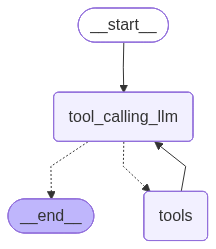

In [24]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

graph_memory =  builder.compile(checkpointer=memory)

#view
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
## specify the thread

config={"configurable": {"thread_id": "1"}}
# Specify an input
messages = [HumanMessage(content="Add 12 and 13.")]
messages = graph_memory.invoke({"messages": messages}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (80egparsc)
 Call ID: 80egparsc
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**. 

Result confirmed!


In [26]:
messages = [HumanMessage(content="Add that number to 25")]
messages = graph_memory.invoke({"messages": messages}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (80egparsc)
 Call ID: 80egparsc
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**. 

Result confirmed!
================================ Human Message =================================

Add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (ejmsa3ry8)
 Call ID: ejmsa3ry8
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

The sum of 25 and 25 is **50**.


In [27]:
messages = [HumanMessage(content="multiply that number by 2")]
messages = graph_memory.invoke({"messages": messages}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (80egparsc)
 Call ID: 80egparsc
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**. 

Result confirmed!
================================ Human Message =================================

Add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (ejmsa3ry8)
 Call ID: ejmsa3ry8
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

The sum of 25 and 25 is **50**.
================================ Human Mess